In [60]:
import pandas as pd

df = pd.read_excel("../data/raw/hydrovoltaic_data.xlsx")

df.head()

c:\Users\wenlu\AppData\Local\Programs\Python\Python313\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


,paper_doi,review_covered,ref_year,device_structure,built_in_asymmetry,asymmetry_origin,primary_mobile_ion,secondary_ion_present,secondary_mobile_ion,ion_origin,...,electrode_symmetry,metal_electrode,voc_V,jsc_uA_cm2,power_density_uW_cm2,internal_resistance_MΩ,output_timescale_class,stability_time_min,dominant_mechanism,notes
0,10.1038/s41467-025-63549-1,0,2025,in-plane,0,environmental_gradient,H+,0,NaN,surface_group_dissociation,...,1,0.0,4.00,NaN,NaN,NaN,seconds,NaN,ion_concentration_gradient,NaN
1,10.1038/nnano.2016.300,1,2017,in-plane,0,environmental_gradient,H+,0,NaN,surface_group_dissociation,...,1,0.0,1.00,0.0150,0.0053,8.0,days,11520.0,streaming,NaN
2,10.1021/acsaelm.9b00419,1,2019,in-plane,0,environmental_gradient,OH-,1,H+,water_dissociation,...,1,1.0,0.40,0.0200,0.0020,34.3,hours,120.0,streaming,NaN
3,10.1002/adma.202514202,0,2026,in-plane,1,chemical + environmental,OH-,1,H+,water_dissociation,...,1,0.0,1.50,0.0250,0.0094,60.0,days,12000.0,streaming,NaN
4,10.1016/j.joule.2022.02.002,1,2022,in-plane,0,environmental_gradient,H+,0,NaN,surface_group_dissociation,...,1,0.0,0.85,0.0368,NaN,NaN,hours,720.0,streaming,NaN


In [61]:
df.shape

(219, 37)

In [62]:
df.columns

Index(['paper_doi', 'review_covered', 'ref_year', 'device_structure',
       'built_in_asymmetry', 'asymmetry_origin', 'primary_mobile_ion',
       'secondary_ion_present', 'secondary_mobile_ion', 'ion_origin',
       'auxiliary_redox_present', 'continuous_output',
       'water_interaction_mode', 'rh_percent', 'inorganic_electrolyte_present',
       'inorganic_electrolyte_type', 'inorganic_electrolyte_concentration_wt%',
       'polyelectrolyte_present', 'polyelectrolyte_anionic',
       'polyelectrolyte_cationic', 'polyelectrolyte_zwitterionic',
       'active_material_raw', 'material_class', 'structure_class',
       'ionic_groups', 'top_electrode', 'bottom_electrode',
       'electrode_symmetry', 'metal_electrode', 'voc_V', 'jsc_uA_cm2',
       'power_density_uW_cm2', 'internal_resistance_MΩ',
       'output_timescale_class', 'stability_time_min', 'dominant_mechanism',
       'notes'],
      dtype='str')

In [63]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 219 entries, 0 to 218
Data columns (total 37 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   paper_doi                                219 non-null    str    
 1   review_covered                           219 non-null    int64  
 2   ref_year                                 219 non-null    int64  
 3   device_structure                         219 non-null    str    
 4   built_in_asymmetry                       219 non-null    int64  
 5   asymmetry_origin                         219 non-null    str    
 6   primary_mobile_ion                       219 non-null    str    
 7   secondary_ion_present                    219 non-null    int64  
 8   secondary_mobile_ion                     88 non-null     str    
 9   ion_origin                               219 non-null    str    
 10  auxiliary_redox_present                  219 non-null    int6

In [64]:
df.isnull().sum()

paper_doi                                    0
review_covered                               0
ref_year                                     0
device_structure                             0
built_in_asymmetry                           0
asymmetry_origin                             0
primary_mobile_ion                           0
secondary_ion_present                        0
secondary_mobile_ion                       131
ion_origin                                   0
auxiliary_redox_present                      0
continuous_output                            0
water_interaction_mode                       0
rh_percent                                  42
inorganic_electrolyte_present                0
inorganic_electrolyte_type                 151
inorganic_electrolyte_concentration_wt%    178
polyelectrolyte_present                      0
polyelectrolyte_anionic                    163
polyelectrolyte_cationic                   197
polyelectrolyte_zwitterionic               205
active_materi

In [65]:
df = df.drop(columns=["notes"])

In [66]:
# polyelectrolyte 类型 → binary encoding

df["has_anionic"] = df["polyelectrolyte_anionic"].notnull().astype(int)
df["has_cationic"] = df["polyelectrolyte_cationic"].notnull().astype(int)
df["has_zwitterionic"] = df["polyelectrolyte_zwitterionic"].notnull().astype(int)

In [67]:
df[["has_anionic", "has_cationic", "has_zwitterionic"]].sum()

has_anionic         56
has_cationic        22
has_zwitterionic    14
dtype: int64

In [68]:
# reserve the original columns for later use
df["polyelectrolyte_anionic_raw"] = df["polyelectrolyte_anionic"]
df["polyelectrolyte_cationic_raw"] = df["polyelectrolyte_cationic"]
df["polyelectrolyte_zwitterionic_raw"] = df["polyelectrolyte_zwitterionic"]

In [69]:
df = df.drop(columns=[
    "polyelectrolyte_anionic",
    "polyelectrolyte_cationic",
    "polyelectrolyte_zwitterionic"
])

In [70]:
df["has_any_polyelectrolyte"] = (
    df["has_anionic"] + 
    df["has_cationic"] + 
    df["has_zwitterionic"]
) > 0

df["has_any_polyelectrolyte"] = df["has_any_polyelectrolyte"].astype(int)

In [71]:
df.columns

Index(['paper_doi', 'review_covered', 'ref_year', 'device_structure',
       'built_in_asymmetry', 'asymmetry_origin', 'primary_mobile_ion',
       'secondary_ion_present', 'secondary_mobile_ion', 'ion_origin',
       'auxiliary_redox_present', 'continuous_output',
       'water_interaction_mode', 'rh_percent', 'inorganic_electrolyte_present',
       'inorganic_electrolyte_type', 'inorganic_electrolyte_concentration_wt%',
       'polyelectrolyte_present', 'active_material_raw', 'material_class',
       'structure_class', 'ionic_groups', 'top_electrode', 'bottom_electrode',
       'electrode_symmetry', 'metal_electrode', 'voc_V', 'jsc_uA_cm2',
       'power_density_uW_cm2', 'internal_resistance_MΩ',
       'output_timescale_class', 'stability_time_min', 'dominant_mechanism',
       'has_anionic', 'has_cationic', 'has_zwitterionic',
       'polyelectrolyte_anionic_raw', 'polyelectrolyte_cationic_raw',
       'polyelectrolyte_zwitterionic_raw', 'has_any_polyelectrolyte'],
      dtype='str

In [72]:
df[["voc_V", "jsc_uA_cm2", "power_density_uW_cm2"]].describe()

,voc_V,jsc_uA_cm2,power_density_uW_cm2
count,217.000000,184.000000,131.000000
mean,0.777843,318.777577,45.604374
std,0.852905,2259.061655,227.037319
min,0.012000,0.003000,0.000360
25%,0.300000,0.400000,0.081250
50%,0.600000,4.000000,0.860000
75%,0.880000,22.000000,7.800000
max,5.000000,27700.000000,1860.000000


In [73]:
df.groupby("continuous_output")["jsc_uA_cm2"].describe()

,count,mean,std,min,25%,50%,75%,max
continuous_output,,,,,,,,
0,25.0,1919.759360,5934.891154,0.010,0.400,5.0,25.0,27700.0
1,159.0,67.050881,302.003796,0.003,0.375,4.0,21.9,3000.0


In [74]:
df_clean = df[df["continuous_output"] == 1].copy()

In [75]:
df_clean.shape
df_clean[["voc_V", "jsc_uA_cm2"]].describe()

,voc_V,jsc_uA_cm2
count,183.000000,159.000000
mean,0.821087,67.050881
std,0.833232,302.003796
min,0.019000,0.003000
25%,0.355000,0.375000
50%,0.610000,4.000000
75%,0.925000,21.900000
max,5.000000,3000.000000


In [76]:
features = [
    "material_class",
    "structure_class",
    "device_structure",
    "built_in_asymmetry",
    "inorganic_electrolyte_present",
    "polyelectrolyte_present",
    "has_anionic",
    "has_cationic",
    "has_zwitterionic",
    "dominant_mechanism",
    "water_interaction_mode",
    "rh_percent"
]

target = "voc_V"

## Model V1

In [77]:
df_model = df_clean[features + [target]].copy()
df_model.shape

(183, 13)

In [78]:
df_model.isnull().sum()

material_class                    0
structure_class                   0
device_structure                  0
built_in_asymmetry                0
inorganic_electrolyte_present     0
polyelectrolyte_present           0
has_anionic                       0
has_cationic                      0
has_zwitterionic                  0
dominant_mechanism                0
water_interaction_mode            0
rh_percent                       37
voc_V                             0
dtype: int64

In [79]:
X = df_model[features]
y = df_model[target]

X_encoded = pd.get_dummies(X, drop_first=False)
X_encoded.head()

,built_in_asymmetry,inorganic_electrolyte_present,polyelectrolyte_present,has_anionic,has_cationic,has_zwitterionic,rh_percent,material_class_MOF/COF,material_class_biomass,material_class_carbon,...,device_structure_sandwich,dominant_mechanism_ion_concentration_gradient,dominant_mechanism_ion_concentration_gradient + pyroelectricity,dominant_mechanism_ion_concentration_gradient + radiative_cooling_enhanced_evaporation,dominant_mechanism_ion_concentration_gradient + schottky_junction,dominant_mechanism_ion_concentration_gradient + thermo_diffusion,dominant_mechanism_streaming,water_interaction_mode_evaporation_driven,water_interaction_mode_liquid_contact,water_interaction_mode_vapor_adsorption
1,0,0,0,0,0,0,60.0,False,False,True,...,False,False,False,False,False,False,True,True,False,False
2,0,0,0,0,0,0,62.0,False,False,False,...,False,False,False,False,False,False,True,True,False,False
3,1,0,0,0,0,0,NaN,False,False,False,...,False,False,False,False,False,False,True,True,False,False
4,0,0,0,0,0,0,NaN,False,False,True,...,False,False,False,False,False,False,True,True,False,False
5,0,0,0,0,0,0,55.0,False,False,True,...,False,False,False,False,False,False,True,True,False,False


In [80]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((146, 32), (37, 32))

In [81]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [82]:
y_pred = rf_model.predict(X_test)

In [83]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("R2:", r2)
print("RMSE:", rmse)
print("MAE:", mae)

R2: -1.3148392554097894
RMSE: 0.808570832286513
MAE: 0.5592762225829722


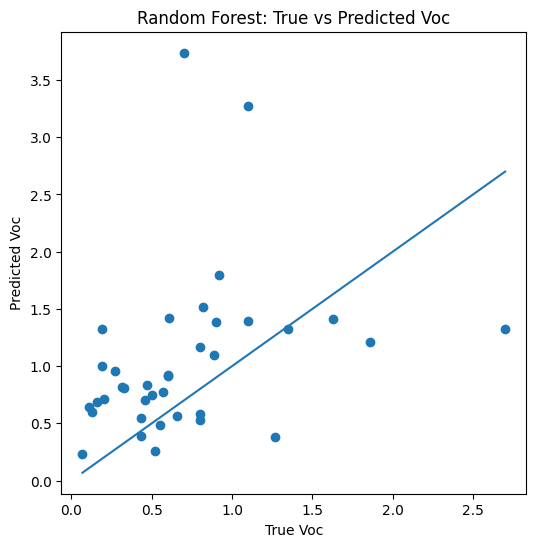

In [84]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("True Voc")
plt.ylabel("Predicted Voc")
plt.title("Random Forest: True vs Predicted Voc")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.show()

## Model v1: Baseline Random Forest

A baseline Random Forest model was trained to predict open-circuit voltage (Voc) using a set of high-level descriptors, including material class, structure class, electrolyte presence, and dominant mechanism.

### Feature Set

* Material and structure descriptors: material_class, structure_class, device_structure
* Electrolyte-related features: inorganic_electrolyte_present, polyelectrolyte_present
* Polyelectrolyte type (binary): has_anionic, has_cationic, has_zwitterionic
* Mechanism-related features: dominant_mechanism, water_interaction_mode
* Built-in asymmetry

### Result

* R² < 0 (poor predictive performance)
* The model performs worse than a mean-value baseline

### Interpretation

* High-level categorical descriptors alone are insufficient to explain variations in Voc
* Important structural or compositional information is likely missing
* The current feature set does not adequately capture the underlying physics of hydrovoltaic systems

### Conclusion

A more detailed feature set is required, particularly including finer-grained descriptors such as ionic groups, electrode materials, and structural details.


## Model V2

In [85]:
[col for col in df_clean.columns if any(k in col for k in ["electrode", "ionic", "material", "structure"])]

['device_structure',
 'active_material_raw',
 'material_class',
 'structure_class',
 'ionic_groups',
 'top_electrode',
 'bottom_electrode',
 'electrode_symmetry',
 'metal_electrode',
 'has_anionic',
 'has_cationic',
 'has_zwitterionic',
 'polyelectrolyte_anionic_raw',
 'polyelectrolyte_cationic_raw',
 'polyelectrolyte_zwitterionic_raw']

In [86]:
features_v2 = [
    # Original（reserve）
    "material_class",
    "structure_class",
    "device_structure",
    "built_in_asymmetry",
    "inorganic_electrolyte_present",
    "polyelectrolyte_present",
    "has_anionic",
    "has_cationic",
    "has_zwitterionic",
    "dominant_mechanism",
    "water_interaction_mode",

    # new（key）
    "ionic_groups",
    "top_electrode",
    "bottom_electrode",
    "electrode_symmetry",
    "metal_electrode"
]

In [87]:
df_model_v2 = df_clean[features_v2 + ["voc_V"]].copy()

df_model_v2.isnull().sum()

material_class                   0
structure_class                  0
device_structure                 0
built_in_asymmetry               0
inorganic_electrolyte_present    0
polyelectrolyte_present          0
has_anionic                      0
has_cationic                     0
has_zwitterionic                 0
dominant_mechanism               0
water_interaction_mode           0
ionic_groups                     0
top_electrode                    0
bottom_electrode                 0
electrode_symmetry               0
metal_electrode                  0
voc_V                            0
dtype: int64

In [88]:
X_v2 = df_model_v2[features_v2]
y_v2 = df_model_v2["voc_V"]

X_v2_encoded = pd.get_dummies(X_v2, drop_first=False)

X_v2_encoded.shape

(183, 114)

In [89]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_v2_encoded, y_v2, test_size=0.2, random_state=42
)

In [90]:
from sklearn.ensemble import RandomForestRegressor

rf_v2 = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf_v2.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [91]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

y_pred = rf_v2.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("R2:", r2)
print("RMSE:", rmse)
print("MAE:", mae)

R2: -0.19718230085498556
RMSE: 0.5814840350031983
MAE: 0.443118306996057


## Model V3

In [92]:
# Count rows with both Voc and Jsc available
df_clean[["voc_V", "jsc_uA_cm2"]].dropna().shape

(159, 2)

In [93]:
# Create estimated power density (uW/cm²)
df_clean["estimated_power_density_uW_cm2"] = (
    df_clean["voc_V"] * df_clean["jsc_uA_cm2"] / 4.0
)

# Log transform to reduce skewness
import numpy as np

df_clean["log_estimated_power_density"] = np.log10(
    df_clean["estimated_power_density_uW_cm2"] + 1e-6
)

In [94]:
df_clean["estimated_power_density_uW_cm2"].describe()
df_clean["log_estimated_power_density"].describe()

count    159.000000
mean      -0.380143
std        1.324738
min       -4.283997
25%       -1.243577
50%       -0.281913
75%        0.559267
max        2.916454
Name: log_estimated_power_density, dtype: float64

In [95]:
# Use only rows where target is available
df_model_v3 = df_clean.dropna(subset=["log_estimated_power_density"]).copy()

# Define X and y
X_v3 = df_model_v3[features_v2]
y_v3 = df_model_v3["log_estimated_power_density"]

In [96]:
# One-hot encoding
X_v3_encoded = pd.get_dummies(X_v3, drop_first=False)

X_v3_encoded.shape

(159, 106)

In [97]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X_train, X_test, y_train, y_test = train_test_split(
    X_v3_encoded,
    y_v3,
    test_size=0.2,
    random_state=42
)

rf_v3 = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf_v3.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [98]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

y_pred = rf_v3.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("R2:", r2)
print("RMSE:", rmse)
print("MAE:", mae)

R2: 0.1908162896423703
RMSE: 1.2101451463073565
MAE: 0.9181840462255948


In [99]:
# Compute feature importance from Random Forest
import pandas as pd

feature_importance = pd.Series(
    rf_v3.feature_importances_,
    index=X_v3_encoded.columns
).sort_values(ascending=False)

feature_importance.head(20)

inorganic_electrolyte_present                    0.110705
structure_class_porous                           0.086835
dominant_mechanism_streaming                     0.068153
material_class_carbon                            0.042770
ionic_groups_carboxyl, hydroxyl, amino           0.037355
ionic_groups_carboxyl, hydroxyl                  0.035222
material_class_biomass                           0.027579
bottom_electrode_Au                              0.025357
metal_electrode                                  0.024513
dominant_mechanism_ion_concentration_gradient    0.022945
water_interaction_mode_vapor_adsorption          0.021647
electrode_symmetry                               0.021265
water_interaction_mode_evaporation_driven        0.021251
bottom_electrode_Pt                              0.020350
ionic_groups_carboxyl, imine                     0.019949
top_electrode_Carbon                             0.019276
top_electrode_Pt                                 0.018593
polyelectrolyt

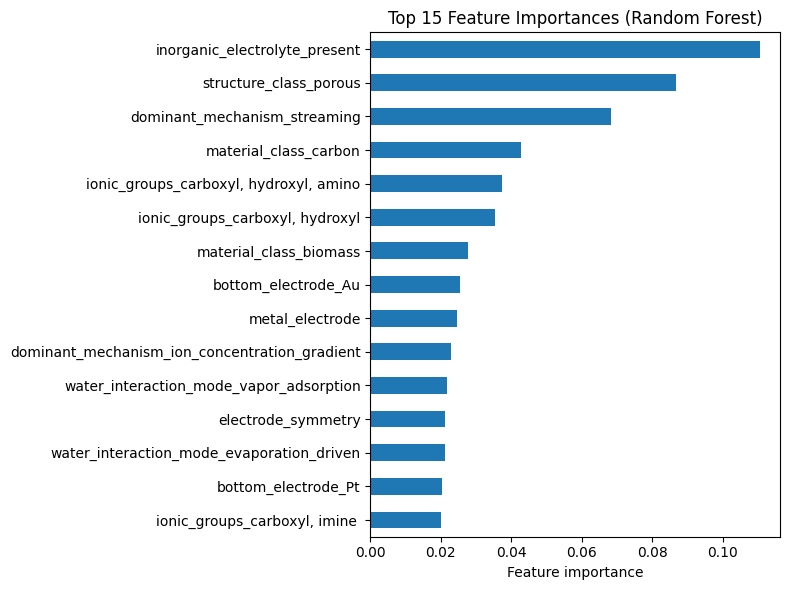

In [100]:
# Plot top 15 feature importances
import matplotlib.pyplot as plt

top_n = 15
fi_top = feature_importance.head(top_n).sort_values()

plt.figure(figsize=(8, 6))
fi_top.plot(kind="barh")
plt.xlabel("Feature importance")
plt.title("Top 15 Feature Importances (Random Forest)")
plt.tight_layout()
plt.show()

## Model v4

In [101]:
df_clean["primary_mobile_ion"].value_counts()

primary_mobile_ion
H+      107
Na+      35
Li+      12
Ca2+     11
OH-       7
Cl-       3
K+        2
Fe3+      2
MA+       2
Co3+      1
Br-       1
Name: count, dtype: int64

In [102]:
# Classify primary mobile ion into physically meaningful groups
def classify_ion(ion):
    if pd.isna(ion):
        return "unknown"
    
    ion = str(ion).strip().lower()
    
    if ion in ["h+", "h"]:
        return "proton"
    
    elif ion in ["na+", "k+", "li+", "ca2+", "fe3+", "co3+", "ma+"]:
        return "other_cation"
    
    elif ion in ["cl-", "oh-", "br-"]:
        return "anion"
    
    else:
        return "other"

df_clean["ion_type"] = df_clean["primary_mobile_ion"].apply(classify_ion)

In [103]:
df_clean["ion_type"].value_counts()

ion_type
proton          107
other_cation     65
anion            11
Name: count, dtype: int64

In [104]:
features_v4 = features_v2 + ["ion_type"]

In [105]:
# Recreate model dataset to include ion_type
df_model_v3 = df_clean.dropna(subset=["log_estimated_power_density"]).copy()

In [106]:
X_v4 = df_model_v3[features_v4]
y_v4 = df_model_v3["log_estimated_power_density"]

X_v4_encoded = pd.get_dummies(X_v4, drop_first=False)

In [107]:
[col for col in features_v4 if col not in df_model_v3.columns]

[]

In [108]:
# Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_v4_encoded,
    y_v4,
    test_size=0.2,
    random_state=42
)

# Train model
from sklearn.ensemble import RandomForestRegressor

rf_v4 = RandomForestRegressor(n_estimators=300, random_state=42)
rf_v4.fit(X_train, y_train)

# Evaluate
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

y_pred = rf_v4.predict(X_test)

print("R2:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2: 0.2254349921029144
RMSE: 1.1839758231218573
MAE: 0.8965402150972257


In [109]:
# Compute feature importance
import pandas as pd

feature_importance = pd.Series(
    rf_v4.feature_importances_,
    index=X_v4_encoded.columns
).sort_values(ascending=False)

feature_importance.head(20)

ion_type_other_cation                            0.112911
structure_class_porous                           0.080886
dominant_mechanism_streaming                     0.052354
material_class_carbon                            0.046678
ionic_groups_carboxyl, hydroxyl                  0.038377
material_class_biomass                           0.028869
ionic_groups_carboxyl, hydroxyl, amino           0.028730
inorganic_electrolyte_present                    0.027557
bottom_electrode_Au                              0.026921
electrode_symmetry                               0.025466
bottom_electrode_Pt                              0.020560
top_electrode_Pt                                 0.020035
water_interaction_mode_vapor_adsorption          0.019826
metal_electrode                                  0.019353
ionic_groups_carboxyl, imine                     0.018927
dominant_mechanism_ion_concentration_gradient    0.018243
water_interaction_mode_evaporation_driven        0.017734
ionic_groups_s

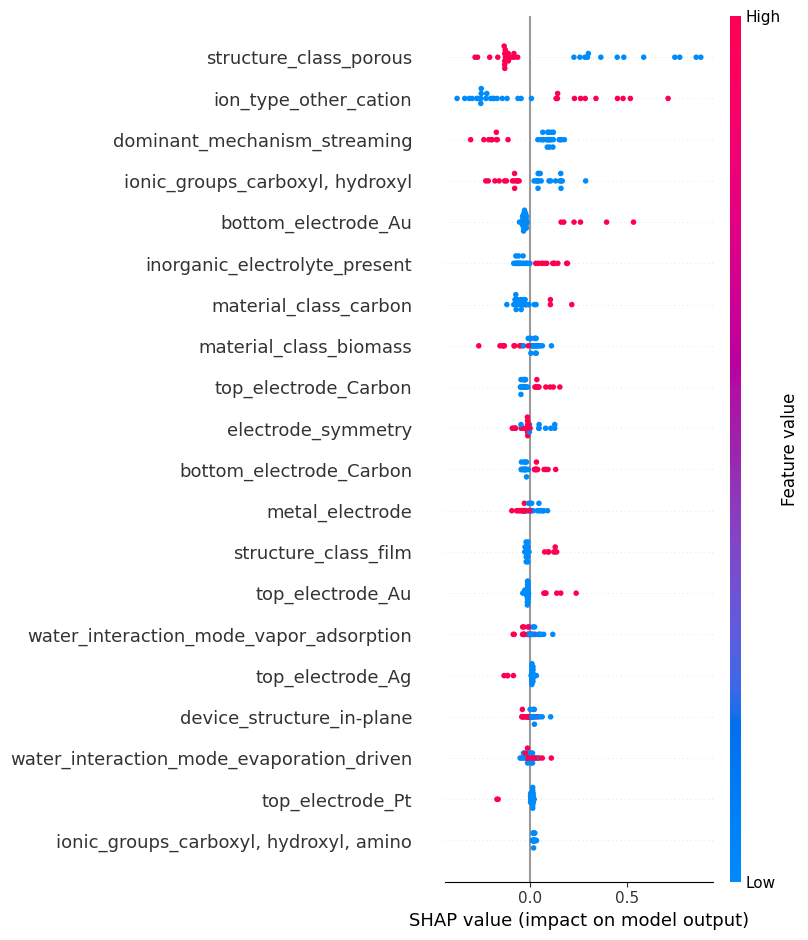

In [110]:
import shap

explainer = shap.TreeExplainer(rf_v4)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

In [111]:
# Cross-tabulation between ion type and dominant mechanism
pd.crosstab(df_model_v3["ion_type"], df_model_v3["dominant_mechanism"])

dominant_mechanism,ion_concentration_gradient,ion_concentration_gradient + pyroelectricity,ion_concentration_gradient + radiative_cooling_enhanced_evaporation,ion_concentration_gradient + schottky_junction,ion_concentration_gradient + thermo_diffusion,streaming
ion_type,,,,,,
anion,3,0,0,0,0,6
other_cation,51,0,1,0,2,0
proton,46,1,0,1,2,46


In [112]:
# Summary of target by dominant mechanism
df_model_v3.groupby("dominant_mechanism")["log_estimated_power_density"].describe()

,count,mean,std,min,25%,50%,75%,max
dominant_mechanism,,,,,,,,
ion_concentration_gradient,100.0,-0.087927,1.330472,-4.283997,-1.011435,0.210817,0.787168,2.552060
ion_concentration_gradient + pyroelectricity,1.0,0.685361,NaN,0.685361,0.685361,0.685361,0.685361,0.685361
ion_concentration_gradient + radiative_cooling_enhanced_evaporation,1.0,1.828144,NaN,1.828144,1.828144,1.828144,1.828144,1.828144
ion_concentration_gradient + schottky_junction,1.0,-0.823906,NaN,-0.823906,-0.823906,-0.823906,-0.823906,-0.823906
ion_concentration_gradient + thermo_diffusion,4.0,0.424939,1.706766,-0.924449,-0.468894,-0.146124,0.747709,2.916454
streaming,52.0,-1.058450,1.010037,-3.217527,-1.585934,-1.113544,-0.674957,1.611192


In [113]:
# Summary of target by ion type
df_model_v3.groupby("ion_type")["log_estimated_power_density"].describe()

,count,mean,std,min,25%,50%,75%,max
ion_type,,,,,,,,
anion,9.0,-0.913929,1.259299,-2.698753,-2.027982,-0.699674,-0.336204,1.343409
other_cation,54.0,0.344277,0.971853,-2.606249,0.037254,0.456742,0.827928,2.916454
proton,96.0,-0.737587,1.343074,-4.283997,-1.524175,-0.974420,0.227641,2.552060


In [114]:
# Grouped mean target by ion type and dominant mechanism
df_model_v3.groupby(["ion_type", "dominant_mechanism"])["log_estimated_power_density"].mean().sort_values(ascending=False)

ion_type      dominant_mechanism                                                 
other_cation  ion_concentration_gradient + radiative_cooling_enhanced_evaporation    1.828144
              ion_concentration_gradient + thermo_diffusion                          1.470624
proton        ion_concentration_gradient + pyroelectricity                           0.685361
other_cation  ion_concentration_gradient                                             0.271011
anion         ion_concentration_gradient                                             0.101715
proton        ion_concentration_gradient                                            -0.498249
              ion_concentration_gradient + thermo_diffusion                         -0.620746
              ion_concentration_gradient + schottky_junction                        -0.823906
              streaming                                                             -1.011062
anion         streaming                                                 

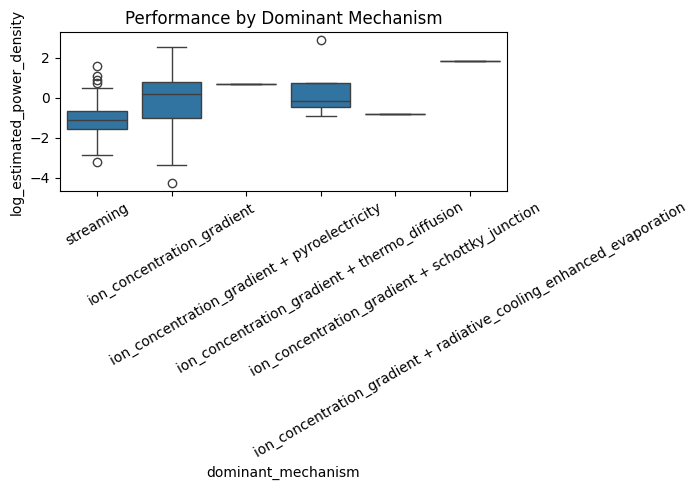

In [115]:
# Import plotting libraries
import seaborn as sns
import matplotlib.pyplot as plt

# Boxplot of performance by mechanism
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df_model_v3,
    x="dominant_mechanism",
    y="log_estimated_power_density"
)

plt.xticks(rotation=30)
plt.title("Performance by Dominant Mechanism")
plt.tight_layout()
plt.show()

In [116]:
def simplify_mechanism(mech):
    mech = mech.lower()
    
    if "streaming" in mech:
        return "streaming"
    elif "ion_concentration_gradient" in mech:
        return "ion_gradient"
    else:
        return "hybrid"

df_model_v3["mechanism_clean"] = df_model_v3["dominant_mechanism"].apply(simplify_mechanism)

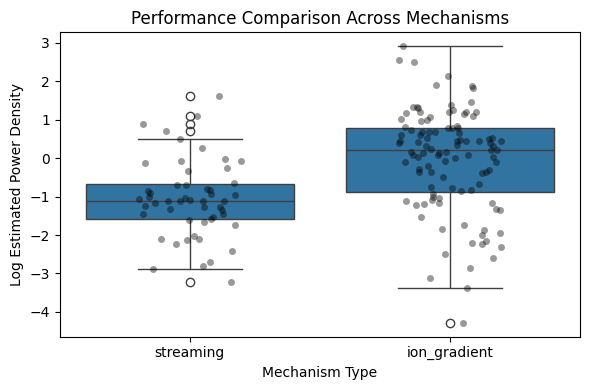

In [117]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=df_model_v3,
    x="mechanism_clean",
    y="log_estimated_power_density"
)

sns.stripplot(
    data=df_model_v3,
    x="mechanism_clean",
    y="log_estimated_power_density",
    color="black",
    alpha=0.4,
    jitter=0.2
)

plt.ylabel("Log Estimated Power Density")
plt.xlabel("Mechanism Type")
plt.title("Performance Comparison Across Mechanisms")

plt.tight_layout()
plt.show()

In [118]:
from sklearn.model_selection import ShuffleSplit, cross_val_score

cv = ShuffleSplit(n_splits=10, test_size=0.2, random_state=42)

scores = cross_val_score(rf_v4, X_v4_encoded, y_v4, cv=cv, scoring='r2')

print(scores)
print("Mean R2:", scores.mean())

[ 0.22543499  0.43612474  0.38989668 -0.00302716  0.04774091  0.07132281
  0.11530383  0.18516687  0.50783828  0.12393116]
Mean R2: 0.20997331072266726


In [119]:
# Cross-tabulation between polyelectrolyte presence and mechanism
pd.crosstab(df_model_v3["polyelectrolyte_present"], df_model_v3["dominant_mechanism"])

dominant_mechanism,ion_concentration_gradient,ion_concentration_gradient + pyroelectricity,ion_concentration_gradient + radiative_cooling_enhanced_evaporation,ion_concentration_gradient + schottky_junction,ion_concentration_gradient + thermo_diffusion,streaming
polyelectrolyte_present,,,,,,
0,54,0,1,0,2,42
1,46,1,0,1,2,10


In [120]:
# Cross-tabulation between polyelectrolyte type and mechanism
for col in ["has_anionic", "has_cationic", "has_zwitterionic"]:
    print("\n", col)
    print(pd.crosstab(df_model_v3[col], df_model_v3["dominant_mechanism"]))


 has_anionic
dominant_mechanism  ion_concentration_gradient  \
has_anionic                                      
0                                           62   
1                                           38   

dominant_mechanism  ion_concentration_gradient + pyroelectricity  \
has_anionic                                                        
0                                                              0   
1                                                              1   

dominant_mechanism  ion_concentration_gradient + radiative_cooling_enhanced_evaporation  \
has_anionic                                                                               
0                                                                   1                     
1                                                                   0                     

dominant_mechanism  ion_concentration_gradient + schottky_junction  \
has_anionic                                                          
0      

In [121]:
# Cross-tabulation between polyelectrolyte features and ion type
for col in ["polyelectrolyte_present", "has_anionic", "has_cationic", "has_zwitterionic"]:
    print("\n", col)
    print(pd.crosstab(df_model_v3[col], df_model_v3["ion_type"]))


 polyelectrolyte_present
ion_type                 anion  other_cation  proton
polyelectrolyte_present                             
0                            7            39      53
1                            2            15      43

 has_anionic
ion_type     anion  other_cation  proton
has_anionic                             
0                7            39      68
1                2            15      28

 has_cationic
ion_type      anion  other_cation  proton
has_cationic                             
0                 8            52      83
1                 1             2      13

 has_zwitterionic
ion_type          anion  other_cation  proton
has_zwitterionic                             
0                     9            54      86
1                     0             0      10


In [122]:
# Compare target by polyelectrolyte-related features
for col in ["polyelectrolyte_present", "has_anionic", "has_cationic", "has_zwitterionic"]:
    print("\n", col)
    print(df_model_v3.groupby(col)["log_estimated_power_density"].describe())


 polyelectrolyte_present
                         count      mean       std       min       25%  \
polyelectrolyte_present                                                  
0                         99.0 -0.461958  1.326897 -4.283997 -1.341851   
1                         60.0 -0.245149  1.321135 -3.384971 -1.060233   

                              50%       75%       max  
polyelectrolyte_present                                
0                       -0.362509  0.486479  2.916454  
1                       -0.082444  0.699506  2.552060  

 has_anionic
             count      mean       std       min       25%       50%  \
has_anionic                                                            
0            114.0 -0.505340  1.290823 -4.283997 -1.337130 -0.564766   
1             45.0 -0.062977  1.370816 -3.384971 -0.924449  0.163944   

                  75%       max  
has_anionic                      
0            0.457690  2.916454  
1            0.787354  2.552060  

 has_cationic

In [123]:
df_ig = df_model_v3[df_model_v3["mechanism_clean"] == "ion_gradient"]

for col in ["polyelectrolyte_present", "has_anionic", "has_cationic", "has_zwitterionic"]:
    print("\n", col)
    print(df_ig.groupby(col)["log_estimated_power_density"].describe())


 polyelectrolyte_present
                         count      mean       std       min       25%  \
polyelectrolyte_present                                                  
0                         57.0 -0.051695  1.367019 -4.283997 -0.775983   
1                         50.0 -0.049136  1.317450 -3.384971 -0.981109   

                              50%       75%       max  
polyelectrolyte_present                                
0                        0.209113  0.773238  2.916454  
1                        0.207258  0.930131  2.552060  

 has_anionic
             count      mean       std       min       25%       50%  \
has_anionic                                                            
0             65.0 -0.120176  1.361237 -4.283997 -1.097448  0.160619   
1             42.0  0.057335  1.309477 -3.384971 -0.804111  0.283062   

                  75%       max  
has_anionic                      
0            0.773238  2.916454  
1            0.930131  2.552060  

 has_cationic

In [124]:
df_oc = df_model_v3[df_model_v3["ion_type"] == "other_cation"]

for col in ["polyelectrolyte_present", "has_anionic", "has_cationic", "has_zwitterionic"]:
    print("\n", col)
    print(df_oc.groupby(col)["log_estimated_power_density"].describe())


 polyelectrolyte_present
                         count      mean       std       min       25%  \
polyelectrolyte_present                                                  
0                         39.0  0.341205  0.998216 -2.606249 -0.045180   
1                         15.0  0.352264  0.933217 -2.167427  0.164877   

                              50%       75%       max  
polyelectrolyte_present                                
0                        0.454845  0.826552  2.916454  
1                        0.513098  0.942132  1.342423  

 has_anionic
             count      mean       std       min       25%       50%  \
has_anionic                                                            
0             39.0  0.341205  0.998216 -2.606249 -0.045180  0.454845   
1             15.0  0.352264  0.933217 -2.167427  0.164877  0.513098   

                  75%       max  
has_anionic                      
0            0.826552  2.916454  
1            0.942132  1.342423  

 has_cationic

In [125]:
features_no_poly = [f for f in features_v4 if f not in [
    "polyelectrolyte_present", "has_anionic", "has_cationic", "has_zwitterionic"
]]

In [126]:
features_poly_focus = [
    f for f in features_v4
    if f not in ["ion_type", "dominant_mechanism"]
]

In [127]:
for col in ["device_structure", "asymmetry_origin", "ion_origin"]:
    print("\n", col)
    print(df_clean[col].value_counts(dropna=False))


 device_structure
device_structure
in-plane         95
sandwich         86
coaxial_cable     2
Name: count, dtype: int64

 asymmetry_origin
asymmetry_origin
environmental_gradient                  83
chemical                                33
chemical + environmental                22
electrode + chemical                    20
electrode                               18
electrode + chemical + environmental     4
electrode + environmental                3
Name: count, dtype: int64

 ion_origin
ion_origin
surface_group_dissociation                         97
electrolyte                                        59
water_dissociation                                 17
surface_group_dissociation + electrolyte            8
surface_group_dissociation + water_dissociation     1
surface_group_dissociation + active electrode       1
Name: count, dtype: int64


In [128]:
for col in ["device_structure", "asymmetry_origin", "ion_origin"]:
    print("\n=== ", col, " x mechanism ===")
    print(pd.crosstab(df_model_v3[col], df_model_v3["dominant_mechanism"]))

    print("\n=== ", col, " x ion_type ===")
    print(pd.crosstab(df_model_v3[col], df_model_v3["ion_type"]))


===  device_structure  x mechanism ===
dominant_mechanism  ion_concentration_gradient  \
device_structure                                 
coaxial_cable                                2   
in-plane                                    32   
sandwich                                    66   

dominant_mechanism  ion_concentration_gradient + pyroelectricity  \
device_structure                                                   
coaxial_cable                                                  0   
in-plane                                                       1   
sandwich                                                       0   

dominant_mechanism  ion_concentration_gradient + radiative_cooling_enhanced_evaporation  \
device_structure                                                                          
coaxial_cable                                                       0                     
in-plane                                                            0                     
sand

In [129]:
for col in ["device_structure", "asymmetry_origin", "ion_origin"]:
    print("\n", col)
    print(df_model_v3.groupby(col)["log_estimated_power_density"].describe())


 device_structure
                  count      mean       std       min       25%       50%  \
device_structure                                                            
coaxial_cable       2.0 -0.180547  1.638042 -1.338817 -0.759682 -0.180547   
in-plane           80.0 -0.598952  1.246535 -4.283997 -1.336961 -0.737828   
sandwich           77.0 -0.157994  1.377124 -3.384971 -1.124933  0.079182   

                       75%       max  
device_structure                      
coaxial_cable     0.398588  0.977724  
in-plane          0.353553  2.916454  
sandwich          0.787354  2.552060  

 asymmetry_origin
                                      count      mean       std       min  \
asymmetry_origin                                                            
chemical                               27.0 -0.106300  1.328726 -4.283997   
chemical + environmental               18.0 -0.439385  1.474358 -3.384971   
electrode                              16.0 -0.758607  1.271771 -2.847406

## Model V5

In [130]:
# Define features and target
features_v5 = features_v4 + ["device_structure"]
target = "log_estimated_power_density"

# Build dataset
df_model_v5 = df_clean[features_v5 + [target]].dropna()

# Split X and y
X_v5 = df_model_v5[features_v5]
y_v5 = df_model_v5[target]

# One-hot encoding for categorical variables
X_v5_encoded = pd.get_dummies(X_v5, drop_first=False)

print(X_v5_encoded.shape)

(159, 118)


In [131]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_v5_encoded, y_v5, test_size=0.2, random_state=42
)

# Train Random Forest model
rf_v5 = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42
)

rf_v5.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [132]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Predict
y_pred = rf_v5.predict(X_test)

# Metrics
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("R2:", r2)
print("RMSE:", rmse)
print("MAE:", mae)

R2: 0.23932879896826675
RMSE: 1.173308953148362
MAE: 0.8824713815842582


In [133]:
from sklearn.model_selection import ShuffleSplit, cross_val_score

cv = ShuffleSplit(n_splits=10, test_size=0.2, random_state=42)

scores = cross_val_score(rf_v5, X_v5_encoded, y_v5, cv=cv, scoring="r2")

print("CV R2 scores:", scores)
print("Mean R2:", scores.mean())

CV R2 scores: [0.2393288  0.43704849 0.37683284 0.00530197 0.05886542 0.07301682
 0.11305807 0.18794435 0.49718575 0.15702466]
Mean R2: 0.21456071698207194


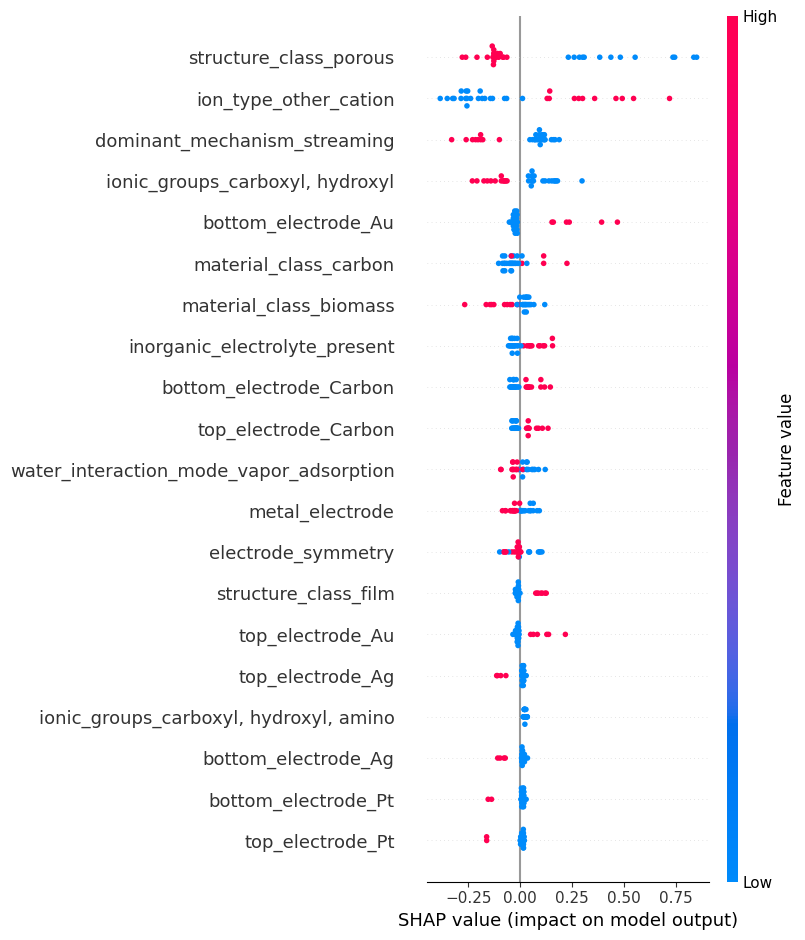

In [134]:
import shap

# Initialize explainer
explainer = shap.TreeExplainer(rf_v5)

# Compute SHAP values (use test set)
shap_values = explainer.shap_values(X_test)

# Summary plot (most important)
shap.summary_plot(shap_values, X_test)

In [135]:
import pandas as pd

feature_importance = pd.Series(
    rf_v5.feature_importances_,
    index=X_v5_encoded.columns
).sort_values(ascending=False)

feature_importance.head(20)

ion_type_other_cation                            0.116086
structure_class_porous                           0.080234
dominant_mechanism_streaming                     0.055362
material_class_carbon                            0.044822
ionic_groups_carboxyl, hydroxyl                  0.039735
ionic_groups_carboxyl, hydroxyl, amino           0.030140
material_class_biomass                           0.029419
bottom_electrode_Au                              0.024974
electrode_symmetry                               0.024700
inorganic_electrolyte_present                    0.023048
top_electrode_Pt                                 0.022656
water_interaction_mode_vapor_adsorption          0.021016
metal_electrode                                  0.019536
bottom_electrode_Pt                              0.018530
ionic_groups_sulfonate                           0.018496
dominant_mechanism_ion_concentration_gradient    0.018172
ionic_groups_carboxyl, imine                     0.018163
bottom_electro

In [136]:
# Create binary features for asymmetry sources
df_clean["asym_env"] = df_clean["asymmetry_origin"].str.contains("environmental", na=False).astype(int)
df_clean["asym_chem"] = df_clean["asymmetry_origin"].str.contains("chemical", na=False).astype(int)
df_clean["asym_electrode"] = df_clean["asymmetry_origin"].str.contains("electrode", na=False).astype(int)

In [137]:
df_clean.to_csv("hydrovoltaic_clean.csv", index=False)